In [1]:
# %pip install matplotlib
# %pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
start_year = str(input("Enter start year: "))
end_year = str(input("Enter end year: "))

In [4]:
import pandas as pd

# Load the parquet file
df = pd.read_parquet(f"../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_{start_year}-{end_year}.parquet")

# View the first 5 rows
print(df.head())

             file_id  year                                          case_name  \
0  2010_10_1002_1008  2010                     SWAMI NATH versus NIRMAL SINGH   
1  2010_10_1009_1021  2010  STATE OF HARYANA versus SATISH KUMAR MITTAL AN...   
2  2010_10_1022_1069  2010  K.K. POONACHA versus STATE OF KARNATAKA AND OT...   
3  2010_10_1070_1094  2010  M/S. KRANTI ASSOCIATES PVT. LTD. & ANR. versus...   
4    2010_10_108_123  2010  STATE OF WEST BENGAL versus SUBHAS KUMAR CHATT...   

                                           full_text  \
0  c\nSWAMI NATH\nv.\nNIRMAL SINGH\n(SLP (Civil) ...   
1  STATE OF HARYANA\nv.\nSATISH KUMAR MITTAL AND ...   
2  K.K. POONACHA\nv.\nSTATE OF KARNATAKA AND OTHE...   
3  {2010) 10 S.C.R. 1070\nMIS. KRANTI ASSOCIATES ...   
4  c\nSTATE OF WEST BENGAL\nV.\nSUBHAS KUMAR CHAT...   

                                                acts  \
0  [A of the East Punjab Urban Rent Restriction A...   
1                                      [Article 283]   
2  [Arti

In [5]:
numcase = 60

In [6]:
print(df.iloc[numcase].T)

file_id                                               2010_10_779_803
year                                                             2010
case_name           GRID CORPORATION OF ORISSA LTD. AND ORS. versu...
full_text           GRID CORPORATION OF ORISSA LTD. AND ORS.\nv.\n...
acts                [Orissa Electricity Reform Act, 1995, These ap...
precedents          [See Bengal Immunity Co. v. State of Bihar, Be...
coram                                  R.V. RAVEENDRAN*, H.L. GOKHALE
decision_date                                              31-08-2010
case_no                                    CIVIL APPEAL No. 5842/1998
disposal_nature                                     Appeal(s) allowed
neutral_citation                                          2010INSC562
Name: 60, dtype: object


In [7]:
filename = df.loc[numcase, "file_id"]
print(filename)

caseName = df.loc[numcase, 'case_name']
print(caseName)

2010_10_779_803
GRID CORPORATION OF ORISSA LTD. AND ORS. versus EASTERN METALS AND FERRO ALLOYS AND ORS.


In [8]:
value = df.loc[numcase, 'precedents']
print(value)

['See Bengal Immunity Co. v. State of Bihar'
 'Bengal Immunity Co. v. State of Bihar 1955'
 'Sur v. Paramnidhi Sadhukhan']


In [9]:
print(f"Loaded {len(df)} records with {df.shape[1]} columns")


Loaded 7942 records with 11 columns



--- Missing Values (Top 15) ---
disposal_nature     1.65
year                0.00
file_id             0.00
case_name           0.00
full_text           0.00
precedents          0.00
acts                0.00
coram               0.00
decision_date       0.00
case_no             0.00
neutral_citation    0.00
dtype: float64


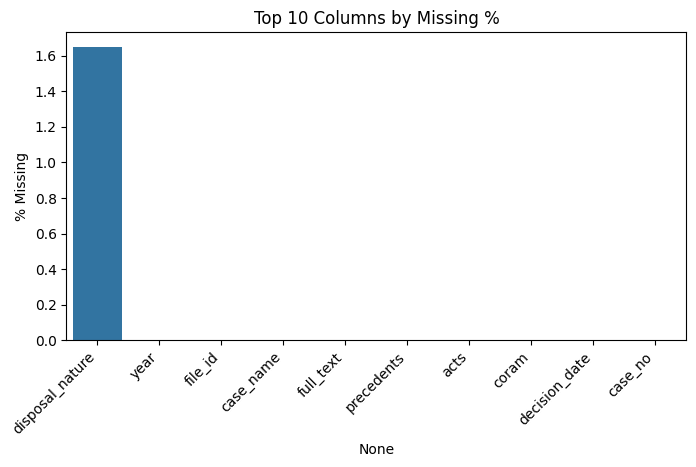

In [10]:
# Missing value audit
print("\n--- Missing Values (Top 15) ---")
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(15).round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=missing.head(10).index, y=missing.head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Columns by Missing %")
plt.ylabel("% Missing")
plt.show()


--- Disposal Nature  Distribution ---
disposal_nature
Appeal(s) allowed                          2944
Dismissed                                  2442
Disposed off                               1511
Case Partly allowed                         421
None                                        131
Directions issued                            97
Matter referred to larger bench              93
Case Allowed                                 79
Hearing Adjourned                            69
Reference answered                           45
Leave Granted & Allowed                      32
Leave granted                                17
Leave Granted & Disposed off                 15
Remitted to Lower Court                       9
Leave Granted & Dismissed                     8
IA disposed                                   6
Rejected                                      5
Dismissed After                               3
Heard                                         3
Modified                         

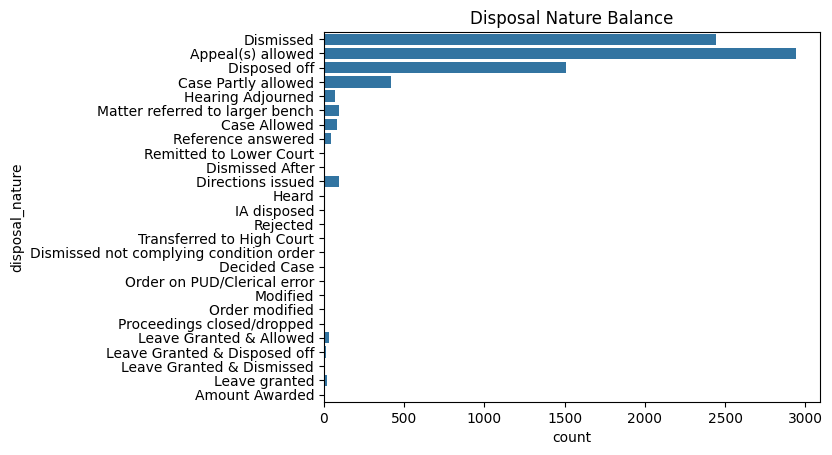

In [11]:
# Data completeness & label balance
print("\n--- Disposal Nature  Distribution ---")
print(df['disposal_nature'].value_counts(dropna=False))
sns.countplot(y='disposal_nature', data=df)
plt.title("Disposal Nature Balance")
plt.show()


--- Text Length Stats ---
count      7942.00
mean       7131.08
std       11730.14
min         127.00
25%        2953.50
50%        4792.00
75%        7943.50
max      399521.00
Name: text_len, dtype: float64


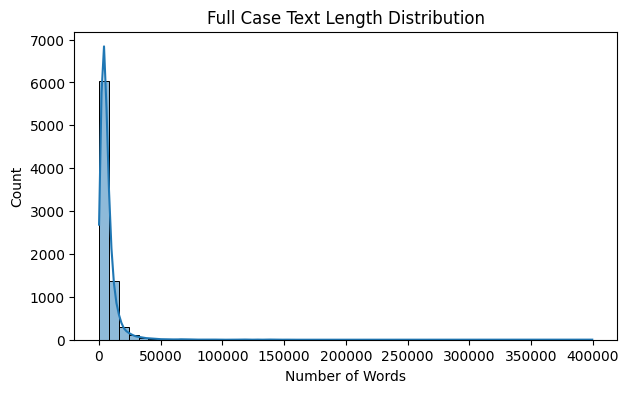

In [12]:
# =======================================
# 4️⃣ Text quality metrics
# =======================================
print("\n--- Text Length Stats ---")
df['text_len'] = df['full_text'].apply(lambda x: len(str(x).split()))
print(df['text_len'].describe().round(2))

plt.figure(figsize=(7,4))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Full Case Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()


--- Top 10 Acts/Articles Distribution ---
acts
Article 226                               771
Article 14                                731
Article 32                                698
Article 136                               659
Article 21                                469
Evidence Act, 1872                        386
Article 142                               310
Land Acquisition Act, 1894                307
Arbitration and Conciliation Act, 1996    297
Article 19                                278
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3924\888404709.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')


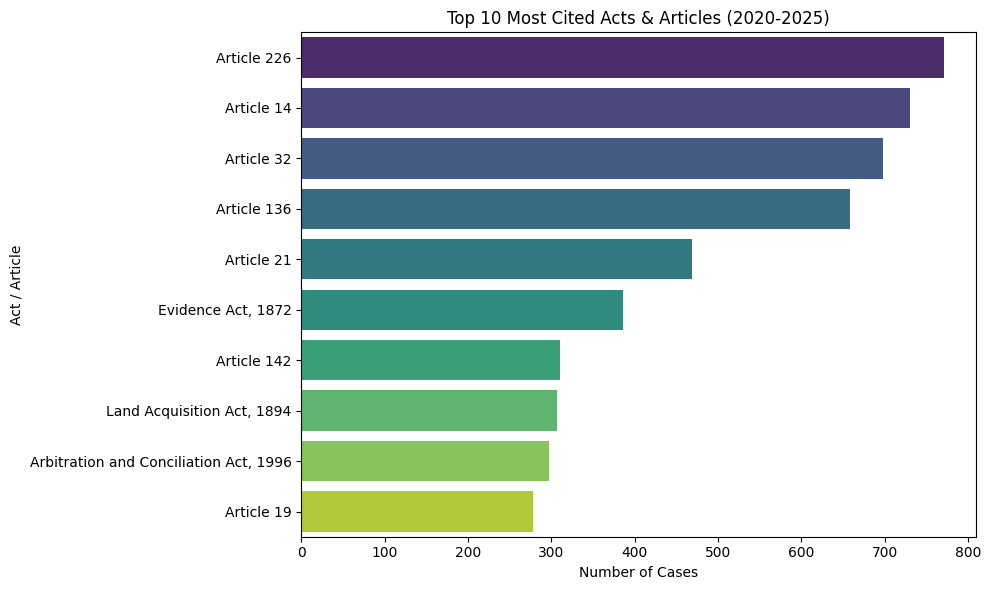

In [13]:
# 1. Explode the 'acts' column so each Act gets its own row
df_exploded = df.explode('acts')

# 2. Drop rows where 'acts' might be None (cases with no identified laws)
df_exploded = df_exploded.dropna(subset=['acts'])

# 3. Calculate the Top 10 Acts for a readable plot
top_10_acts = df_exploded['acts'].value_counts().nlargest(10)

print("\n--- Top 10 Acts/Articles Distribution ---")
print(top_10_acts)

# 4. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')

plt.title("Top 10 Most Cited Acts & Articles (2020-2025)")
plt.xlabel("Number of Cases")
plt.ylabel("Act / Article")
plt.tight_layout()
plt.show()